In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [30]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [31]:
random.randint(140, 195)

157

In [36]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [45]:
print('여자 몸무게(X축) : ',[female[0] for female in data[::2]])
print('여자 키(Y축) : ',[female[1] for female in data[::2]])

print('남자 몸무게(X축) : ',[male[0] for male in data[1::2]])
print('남자 키(Y축) : ',[male[1] for male in data[1::2]])

여자 몸무게(X축) :  [65, 47, 47, 66, 64, 59, 63, 58, 49, 55, 40, 45, 67, 62, 50, 62, 47, 40, 48, 65, 64, 47, 65, 67, 44, 69, 65, 56, 68, 54, 46, 48, 62, 58, 53, 61, 41, 45, 69, 68, 61, 66, 64, 64, 68, 54, 61, 48, 57, 68]
여자 키(Y축) :  [148, 149, 169, 145, 146, 146, 149, 156, 145, 167, 152, 170, 161, 144, 169, 154, 151, 166, 164, 158, 149, 144, 161, 148, 163, 163, 167, 160, 140, 158, 155, 149, 151, 160, 155, 143, 149, 154, 142, 162, 158, 161, 154, 169, 169, 170, 141, 167, 168, 142]
남자 몸무게(X축) :  [65, 64, 76, 89, 82, 63, 78, 77, 66, 93, 69, 64, 67, 67, 78, 80, 70, 83, 66, 74, 92, 95, 65, 87, 62, 86, 95, 79, 77, 74, 90, 84, 85, 82, 74, 80, 75, 61, 78, 80, 93, 63, 80, 65, 92, 76, 67, 65, 84, 60]
남자 키(Y축) :  [178, 171, 195, 190, 189, 191, 170, 180, 180, 163, 181, 163, 169, 166, 175, 181, 160, 188, 177, 181, 183, 193, 189, 189, 190, 166, 165, 164, 179, 168, 191, 181, 166, 166, 178, 163, 166, 182, 191, 188, 177, 180, 194, 168, 172, 163, 173, 164, 189, 175]


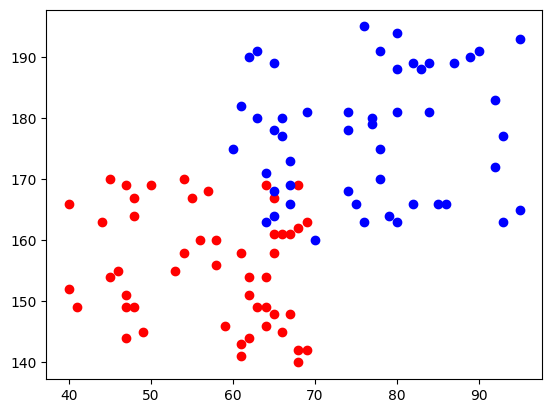

In [50]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [89]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([67, 166], [61, 141])

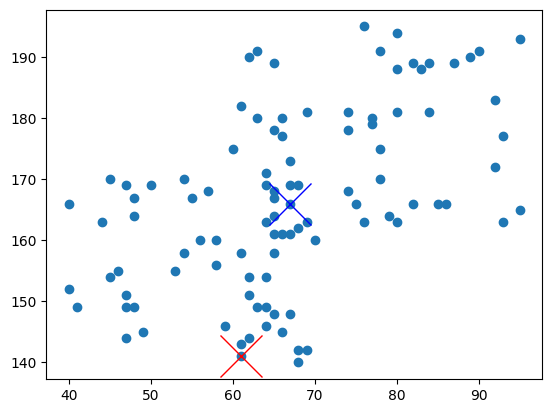

In [92]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점 0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점 1

In [ ]:
# 두점 거리를 return 하는 함수 점은 [50,160]
def dist(a, b):